# 07 — Final Model Evaluation and Feature Importance

This notebook performs the one-time final evaluation of the selected XGBoost model. The tuned configuration from Step 06 is refitted on combined training and validation data, its class-imbalance weight is recalculated from that combined development set, and the frozen validation-derived threshold is applied unchanged to the untouched test period. The notebook then reports final performance and the selected model's feature importance.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
data_dir = project_root / "data" / "processed"
results_dir = project_root / "reports" / "model_results"
figures_dir = project_root / "reports" / "figures"
models_dir = project_root / "models"
for directory in [results_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

## 1. Load Frozen Selection and Data

The selected model name and threshold are read from Step 06 artifacts rather than chosen again. Test labels are accessed only after the final model has been refitted and all settings are frozen.

In [2]:
with open(models_dir / "06_selected_threshold.json") as file:
    selection = json.load(file)
selected_model_name = selection["model"]
frozen_threshold = float(selection["threshold"])
if selected_model_name != "XGBoost":
    raise RuntimeError(f"Expected selected XGBoost pipeline, found {selected_model_name}.")
selected_tuned_pipeline = joblib.load(models_dir / "06_selected_tuned_pipeline.joblib")
selected_features = pd.read_csv(results_dir / "04_selected_features.csv")["feature"].tolist()
train_df = pd.read_csv(data_dir / "04_train_engineered.csv", parse_dates=["timestamp"])
validation_df = pd.read_csv(data_dir / "04_validation_engineered.csv", parse_dates=["timestamp"])
test_df = pd.read_csv(data_dir / "04_test_engineered.csv", parse_dates=["timestamp"])
development_df = pd.concat([train_df, validation_df], ignore_index=True)
if development_df["timestamp"].max() >= test_df["timestamp"].min():
    raise RuntimeError("Development and test periods are not strictly chronological.")
X_development = development_df[selected_features].copy()
y_development = development_df["failure"].astype("int8").copy()
X_test = test_df[selected_features].copy()
print("Frozen model:", selected_model_name)
print(f"Frozen threshold: {frozen_threshold:.3f}")
print(f"Combined development rows: {len(development_df):,}; failures: {y_development.sum():,}")
print(f"Untouched test rows prepared: {len(test_df):,}")
print("Strict chronological separation:", development_df["timestamp"].max() < test_df["timestamp"].min())

Frozen model: XGBoost
Frozen threshold: 0.035
Combined development rows: 113,790; failures: 2,698
Untouched test rows prepared: 17,970
Strict chronological separation: True


## 2. Refit the Frozen Configuration

The exact tuned pipeline structure and hyperparameters are cloned. Only `scale_pos_weight` is recalculated because the final development set now includes validation labels. No model choice, feature choice, or threshold choice is changed.

In [3]:
final_scale_pos_weight = y_development.eq(0).sum() / y_development.eq(1).sum()
final_pipeline = clone(selected_tuned_pipeline).set_params(model__scale_pos_weight=final_scale_pos_weight)
final_pipeline.fit(X_development, y_development)
joblib.dump(final_pipeline, models_dir / "07_final_xgboost_pipeline.joblib")
print(f"Combined-development scale_pos_weight: {final_scale_pos_weight:.4f}")
print("Final pipeline fitted and saved.")

Combined-development scale_pos_weight: 41.1757
Final pipeline fitted and saved.


## 3. One-Time Test Evaluation

The following cell is the sole final test evaluation. Probabilities are converted to classifications with the frozen 0.035 threshold selected in Step 06.

In [4]:
y_test = test_df["failure"].astype("int8").copy()
test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= frozen_threshold).astype("int8")
test_metrics = pd.Series({"model": selected_model_name, "threshold": frozen_threshold, "rows": len(y_test), "failure_count": int(y_test.sum()), "failure_prevalence_pct": y_test.mean() * 100, "recall": recall_score(y_test, test_predictions), "precision": precision_score(y_test, test_predictions, zero_division=0), "f1": f1_score(y_test, test_predictions), "pr_auc": average_precision_score(y_test, test_probabilities), "roc_auc": roc_auc_score(y_test, test_probabilities), "predicted_positive_pct": test_predictions.mean() * 100})
display(test_metrics.to_frame("test_value"))
test_report = pd.DataFrame(classification_report(y_test, test_predictions, target_names=["normal", "failure"], output_dict=True, zero_division=0)).T
display(test_report)

,test_value
model,XGBoost
threshold,0.0350
rows,17970
failure_count,1255
failure_prevalence_pct,6.9839
recall,0.8518
precision,0.6116
f1,0.7120
pr_auc,0.8548
roc_auc,0.9859


,precision,recall,f1-score,support
normal,0.9885,0.9594,0.9737,"16,715.0000"
failure,0.6116,0.8518,0.7120,"1,255.0000"
accuracy,0.9519,0.9519,0.9519,0.9519
macro avg,0.8000,0.9056,0.8428,"17,970.0000"
weighted avg,0.9622,0.9519,0.9555,"17,970.0000"


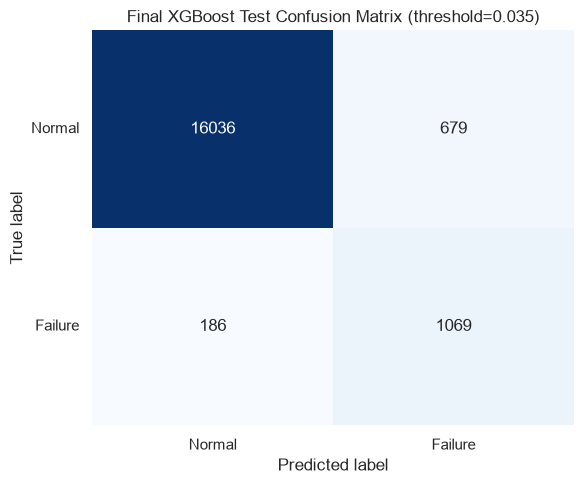

{'true_negatives': 16036, 'false_positives': 679, 'false_negatives': 186, 'true_positives': 1069}


In [5]:
matrix = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = matrix.ravel()
fig, axis = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
axis.set(title=f"Final XGBoost Test Confusion Matrix (threshold={frozen_threshold:.3f})", xlabel="Predicted label", ylabel="True label")
axis.set_xticklabels(["Normal", "Failure"]); axis.set_yticklabels(["Normal", "Failure"], rotation=0)
fig.tight_layout()
confusion_path = figures_dir / "07_final_test_confusion_matrix.png"
fig.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.show()
print({"true_negatives": int(tn), "false_positives": int(fp), "false_negatives": int(fn), "true_positives": int(tp)})

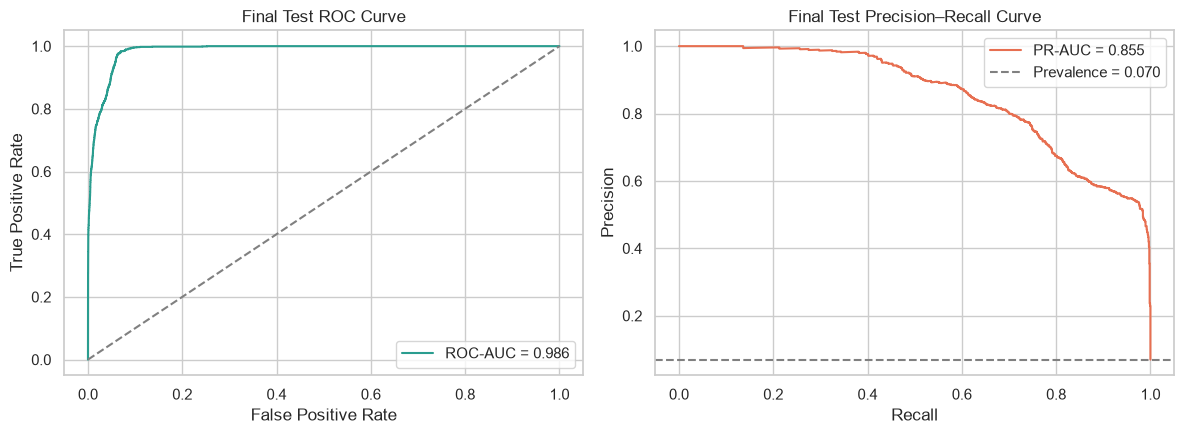

In [6]:
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_test, test_probabilities)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color="#2a9d8f", label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set(title="Final Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].plot(curve_recall, curve_precision, color="#e76f51", label=f"PR-AUC = {test_metrics['pr_auc']:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"Prevalence = {y_test.mean():.3f}")
axes[1].set(title="Final Test Precision–Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend()
fig.tight_layout()
curves_path = figures_dir / "07_final_test_roc_pr_curves.png"
fig.savefig(curves_path, dpi=160, bbox_inches="tight")
plt.show()

## 4. Operational Test Diagnostics

Row-level metrics are supplemented with turbine-day alert burden and failure-episode detection. A test failure episode is a consecutive per-turbine run of `failure=1` records at 10-minute cadence; an episode counts as detected if at least one of its records is predicted positive.

In [7]:
test_predictions_frame = test_df[["source_index", "timestamp", "turbine_id", "failure"]].copy()
test_predictions_frame["failure_probability"] = test_probabilities
test_predictions_frame["prediction"] = test_predictions
test_predictions_frame = test_predictions_frame.sort_values(["turbine_id", "timestamp"])
previous_failure = test_predictions_frame.groupby("turbine_id")["failure"].shift(fill_value=0)
time_gap_minutes = test_predictions_frame.groupby("turbine_id")["timestamp"].diff().dt.total_seconds().div(60)
new_episode = test_predictions_frame["failure"].eq(1) & (previous_failure.ne(1) | time_gap_minutes.ne(10))
test_predictions_frame["failure_episode_id"] = new_episode.groupby(test_predictions_frame["turbine_id"]).cumsum().where(test_predictions_frame["failure"].eq(1))
episode_summary = test_predictions_frame.dropna(subset=["failure_episode_id"]).groupby(["turbine_id", "failure_episode_id"]).agg(start=("timestamp", "min"), end=("timestamp", "max"), records=("failure", "size"), detected=("prediction", "max")).reset_index()
episode_recall = episode_summary["detected"].mean()
turbine_days = test_predictions_frame.assign(day=test_predictions_frame["timestamp"].dt.date).groupby(["turbine_id", "day"]).size().shape[0]
false_alerts_per_turbine_day = fp / turbine_days
operational_metrics = pd.Series({"failure_episodes": len(episode_summary), "detected_episodes": int(episode_summary["detected"].sum()), "episode_recall": episode_recall, "false_positives": int(fp), "turbine_days": turbine_days, "false_positive_records_per_turbine_day": false_alerts_per_turbine_day})
display(operational_metrics.to_frame("test_value"))

,test_value
failure_episodes,65.0000
detected_episodes,60.0000
episode_recall,0.9231
false_positives,679.0000
turbine_days,135.0000
false_positive_records_per_turbine_day,5.0296


## 5. Selected-Model Feature Importance

XGBoost's fitted gain-based importance is reported for the final combined-development model. It measures how much each transformed feature improved tree splits; it is associative rather than causal, and correlated features can divide importance between themselves.

,rank,feature,importance,cumulative_importance
0,1,drivetrain_vibration_rms_mmps_past_3h_mean,0.4758,0.4758
1,2,drivetrain_vibration_rms_mmps_past_1h_mean,0.1670,0.6429
2,3,tower_vibration_mmps,0.1415,0.7844
3,4,yaw_misalignment_cos,0.0484,0.8328
4,5,drivetrain_vibration_rms_mmps,0.0268,0.8595
5,6,vib_fft_gearmesh,0.0226,0.8822
6,7,gearmesh_sideband_ratio,0.0138,0.8959
7,8,drivetrain_vibration_rms_mmps_lag1,0.0108,0.9067
8,9,vib_fft_bearing_bpfi,0.0060,0.9128
9,10,bearing_fft_sum,0.0055,0.9183


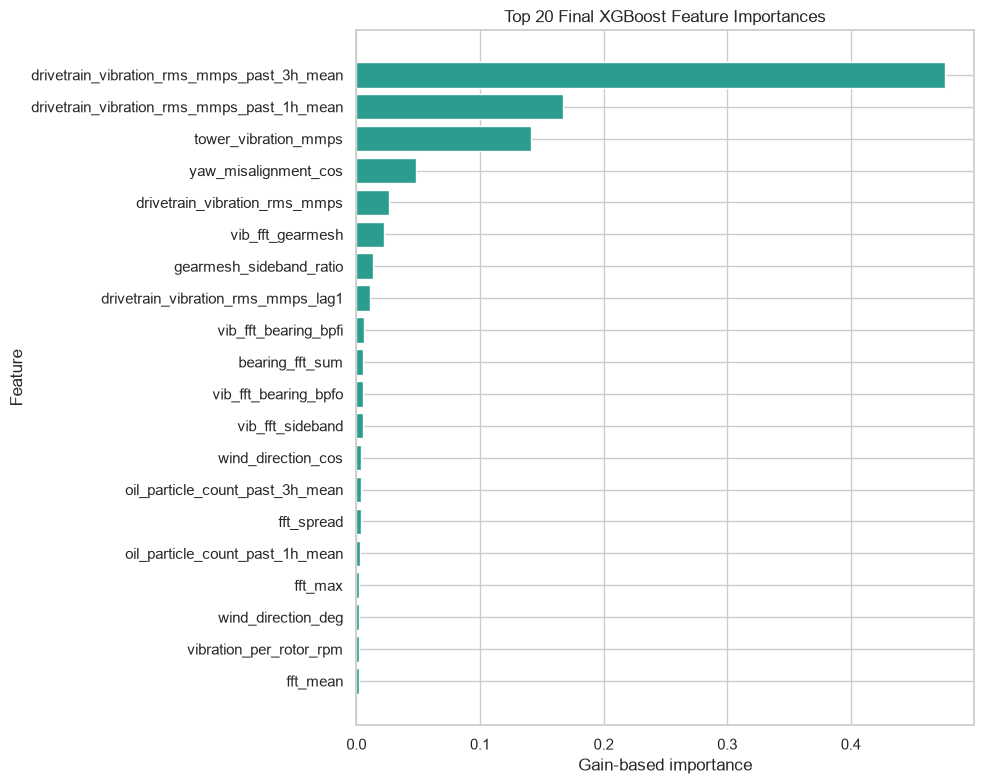

In [8]:
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()
if len(transformed_feature_names) != len(fitted_model.feature_importances_):
    raise RuntimeError("Transformed feature names do not align with model importances.")
feature_importance = pd.DataFrame({"feature": transformed_feature_names, "importance": fitted_model.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
feature_importance["rank"] = np.arange(1, len(feature_importance) + 1)
feature_importance["cumulative_importance"] = feature_importance["importance"].cumsum()
top_features = feature_importance.head(20).copy()
display(top_features[["rank", "feature", "importance", "cumulative_importance"]])
fig, axis = plt.subplots(figsize=(10, 8))
plot_data = top_features.sort_values("importance")
axis.barh(plot_data["feature"], plot_data["importance"], color="#2a9d8f")
axis.set(title="Top 20 Final XGBoost Feature Importances", xlabel="Gain-based importance", ylabel="Feature")
fig.tight_layout()
importance_path = figures_dir / "07_final_xgboost_feature_importance.png"
fig.savefig(importance_path, dpi=160, bbox_inches="tight")
plt.show()

### Original Versus Engineered Features and Source-Sensor Families

The detailed table below preserves the model's actual inputs while identifying whether each input came directly from the source CSV or was engineered in Step 04. A second view sums importance within physical source-sensor families. This avoids presenting several correlated rolling versions of one sensor as independent business findings.

In [ ]:
raw_columns = set(pd.read_csv(project_root / "data" / "raw" / "wind_turbine_detection.csv", nrows=0).columns)
def feature_origin(feature):
    return "Original" if feature in raw_columns or feature.startswith("rated_power_kW_") else "Engineered"

def sensor_family(feature):
    if "drivetrain_vibration" in feature or feature == "vibration_per_rotor_rpm": return "Drivetrain vibration"
    if feature.startswith("tower_vibration"): return "Tower vibration"
    if feature.startswith("vib_fft_") or feature.startswith("fft_") or feature in {"bearing_fft_sum", "gearmesh_sideband_ratio"}: return "FFT vibration signals"
    if "yaw_misalignment" in feature: return "Yaw misalignment"
    if "wind_direction" in feature: return "Wind direction"
    if "oil_particle" in feature: return "Oil particle count"
    if "oil_pressure" in feature: return "Oil pressure"
    if "gearbox_bearing_temp" in feature or feature in {"gearbox_temp_rise", "gearbox_nacelle_temp_gap"}: return "Gearbox temperature"
    if "main_bearing_temp" in feature: return "Main-bearing temperature"
    if "generator_winding_temp" in feature or feature == "winding_bearing_temp_gap": return "Generator temperature"
    if feature in {"generator_speed_rpm", "rotor_speed_rpm", "generator_rotor_ratio", "rotor_stopped"}: return "Drivetrain speed"
    if feature in {"power_output_kW", "capacity_factor", "positive_power", "near_rated_operation"}: return "Power output"
    if feature.startswith("rated_power_kW"): return "Rated power"
    return feature.replace("_", " ").title()

importance_interpretation = feature_importance.copy()
importance_interpretation["feature_type"] = importance_interpretation["feature"].map(feature_origin)
importance_interpretation["source_sensor_family"] = importance_interpretation["feature"].map(sensor_family)
display(importance_interpretation.head(20)[["rank", "feature", "feature_type", "source_sensor_family", "importance"]])
family_importance = importance_interpretation.groupby("source_sensor_family", as_index=False)["importance"].sum().sort_values("importance", ascending=False).reset_index(drop=True)
family_importance["rank"] = np.arange(1, len(family_importance) + 1)
family_importance["cumulative_importance"] = family_importance["importance"].cumsum()
display(family_importance.head(15)[["rank", "source_sensor_family", "importance", "cumulative_importance"]])
fig, axis = plt.subplots(figsize=(10, 7))
family_plot = family_importance.head(15).sort_values("importance")
axis.barh(family_plot["source_sensor_family"], family_plot["importance"], color="#457b9d")
axis.set(title="Final XGBoost Importance by Source-Sensor Family", xlabel="Summed gain-based importance", ylabel="Source-sensor family")
fig.tight_layout()
family_importance_path = figures_dir / "07_final_xgboost_sensor_family_importance.png"
fig.savefig(family_importance_path, dpi=160, bbox_inches="tight")
plt.show()
importance_interpretation.to_csv(results_dir / "07_final_xgboost_importance_interpretation.csv", index=False)
family_importance.to_csv(results_dir / "07_final_xgboost_sensor_family_importance.csv", index=False)

#### Interpretation Result

| Rank | Source-sensor family | Aggregated importance |
|---:|---|---:|
| 1 | Drivetrain vibration | 0.6845 |
| 2 | Tower vibration | 0.1415 |
| 3 | FFT vibration signals | 0.0664 |
| 4 | Yaw misalignment | 0.0505 |
| 5 | Oil particle count | 0.0127 |

The grouped view shows that drivetrain-vibration-derived and original inputs collectively account for 68.45% of fitted gain importance. This is the appropriate business interpretation; the detailed feature table remains the accurate model-level explanation.

![Final XGBoost importance aggregated by source-sensor family](../reports/figures/07_final_xgboost_sensor_family_importance.png)

## 6. Save Final Results

In [9]:
pd.DataFrame([test_metrics.to_dict()]).to_csv(results_dir / "07_final_test_metrics.csv", index=False)
test_report.reset_index(names="class").to_csv(results_dir / "07_final_test_classification_report.csv", index=False)
operational_metrics.to_frame().T.to_csv(results_dir / "07_final_test_operational_metrics.csv", index=False)
episode_summary.to_csv(results_dir / "07_final_test_episode_results.csv", index=False)
feature_importance.to_csv(results_dir / "07_final_xgboost_feature_importance.csv", index=False)
test_predictions_frame.to_csv(results_dir / "07_final_test_predictions.csv", index=False)
print("Final pipeline:", (models_dir / "07_final_xgboost_pipeline.joblib").relative_to(project_root))
print("Top feature:", feature_importance.iloc[0]["feature"])
print("Final result files saved and test predictions remain traceable by source row, timestamp, and turbine.")

Final pipeline: models/07_final_xgboost_pipeline.joblib
Top feature: drivetrain_vibration_rms_mmps_past_3h_mean
Final result files saved and test predictions remain traceable by source row, timestamp, and turbine.


## Key Findings Recap

- The selected XGBoost configuration was refitted on 113,790 combined training and validation rows with 2,698 failures; its imbalance weight was recalculated to 41.1757 while the feature set and frozen 0.035 threshold remained unchanged.
- On the untouched 17,970-row test period, the final model achieved 0.8518 failure recall, 0.6116 precision, 0.7120 F1, 0.8548 PR-AUC, and 0.9859 ROC-AUC.
- The frozen threshold produced 1,069 true positives, 186 false negatives, 679 false positives, and 16,036 true negatives, corresponding to a 9.7273% predicted-positive rate.
- At episode level, the model detected 60 of 65 test failure episodes for 0.9231 episode recall.
- The model generated 679 false-positive 10-minute records, equivalent to 5.0296 false-positive records per turbine-day before any alert deduplication or cooldown policy.
- The three leading gain-based features were the past three-hour mean of drivetrain vibration, the past one-hour mean of drivetrain vibration, and current tower vibration; together they represented 0.7844 of total fitted importance.
- Aggregating original and engineered inputs by their physical source showed drivetrain vibration contributed 0.6845 of total fitted importance, followed by tower vibration at 0.1415 and FFT vibration signals at 0.0664; these associations do not establish causation.
- The final pipeline, test metrics, classification report, operational diagnostics, episode results, traceable row predictions, detailed original/engineered labels, source-family importance table, and evaluation figures were saved.